In [2]:
import numpy as np
import matplotlib.pyplot as plt

fs = 48000

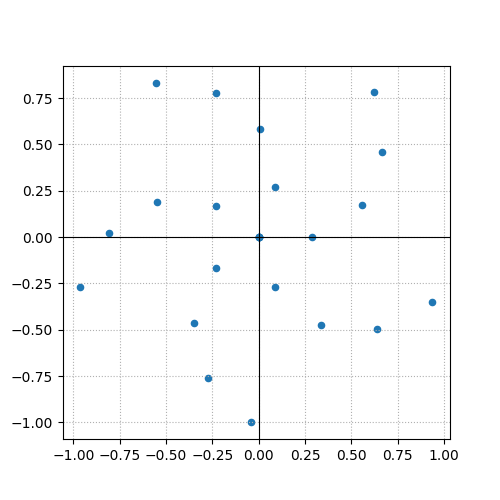

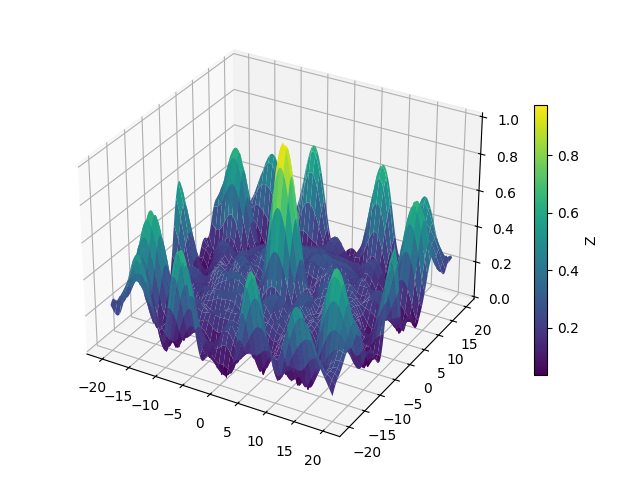

In [78]:
%matplotlib widget

plt.close('all')

def showerflower(curve, edges, armlength):
    pattern = []
    for i in range(armlength):
        pattern.append((np.sqrt(1+i)-0.6)*np.exp((curve * i) * 1j))
        # pattern.append((np.sqrt(i)-0.3)*np.exp(np.random.rand() * 2j * np.pi))
    
    pattern.append(0)
    pattern = np.array(pattern)
    pattern = pattern / np.max(np.abs(pattern))
    pattern = np.array([pattern * np.exp(2 * np.pi * i * 1j / edges) for i in range(edges)]).flatten()
    pattern = np.array([pattern.real, pattern.imag])
    return pattern

def randomsplat(size = 20):
    pattern = np.exp(np.random.rand(size)*np.pi*2j) * np.random.rand(size)
    pattern = np.array([pattern.real, pattern.imag])
    return pattern

pattern = showerflower(0.3, 5, 4)
#pattern = randomsplat()
x, y = pattern

pattern = pattern.transpose()

plt.figure(figsize=(5, 5))
plt.scatter(x, y, s=20, c='C0')
plt.axhline(0, color='k', lw=0.8)
plt.axvline(0, color='k', lw=0.8)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, ls=':')
plt.show()

r = 20
n = 1024

x = np.linspace(-r, r, n)
y = np.linspace(-r, r, n)

xv, yv = np.meshgrid(x, y)
p = np.stack(np.meshgrid(x, y), axis=-1)

z = np.abs(np.sum(np.array([np.exp(np.dot(p, pattern[i])*1j) for i in range(len(pattern))]), axis=0)) / len(pattern)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xv, yv, z, cmap='viridis', linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.6, label='Z')
plt.tight_layout(); plt.show()